In [2]:
import jax.numpy as jnp
import jax.random as jr

from jax import vmap
from matplotlib import pyplot as plt
from optax import adam

from dynamax.linear_gaussian_ssm import LinearGaussianSSM
from dynamax.utils.utils import monotonically_increasing, random_rotation

In [3]:
state_dim = 2
emission_dim = 10
num_timesteps = 100
k1, k2, k3 = jr.split(jr.PRNGKey(0), 3)

# Construct the true model with randomly initialized parameters
true_A = 0.99 * random_rotation(seed=k1, n=state_dim, theta=jnp.pi / 10)
true_Sigma = 0.01 * jnp.eye(state_dim)
true_model = LinearGaussianSSM(state_dim, emission_dim)
true_params, param_props = true_model.initialize(
    key=k1, dynamics_weights=true_A, dynamics_covariance=true_Sigma)            

# Sample states and emissions from the true model
true_states, emissions = true_model.sample(true_params, k3, num_timesteps)

In [4]:
def plot_emissions_and_forecast(model, params, emissions, 
                                num_forecast_timesteps=50, 
                                spc=4):
    """
    Plot the true emissions, the reconstructed emissions, and the future forecast.
    """
    num_timesteps = emissions.shape[0]
    t_obs = jnp.arange(num_timesteps)
    t_forecast = jnp.arange(num_timesteps, num_timesteps + num_forecast_timesteps)
    recon_emissions, recon_emissions_std = model.posterior_predictive(params, emissions)
    _, _, forecast_emissions, forecast_emissions_cov = model.forecast(params, emissions, num_forecast_timesteps)
    forecast_emissions_std = jnp.sqrt(vmap(jnp.diag)(forecast_emissions_cov))

    for i in range(emission_dim):
        # Plot the emissions
        # axs[1].axhline(i *spc, color="black", linestyle=":", alpha=0.5)
        plt.plot(emissions[:, i] + spc * i, "--k", label="observed" if i == 0 else None)
        ln = plt.plot(t_obs, recon_emissions[:, i] + spc * i, 
                      label="smoothed" if i == 0 else None)[0]
        plt.fill_between(
            t_obs,
            spc * i + recon_emissions[:, i] - 2 * recon_emissions_std[:, i],
            spc * i + recon_emissions[:, i] + 2 * recon_emissions_std[:, i],
            color=ln.get_color(),
            alpha=0.25,
        )
        
        # Plot the forecast
        plt.plot(t_forecast, forecast_emissions[:, i] + spc * i, 
                 ls=':', c=ln.get_color(), label="forecast" if i == 0 else None)[0]

        plt.fill_between(
            t_forecast,
            spc * i + forecast_emissions[:, i] - 2 * forecast_emissions_std[:, i],
            spc * i + forecast_emissions[:, i] + 2 * forecast_emissions_std[:, i],
            color=ln.get_color(),
            alpha=0.25,
        )

    # Draw a dividing line between observations and forecasts
    plt.axvline(num_timesteps, color="black", linestyle="-", lw=2)
        
    # Label the axes
    plt.xlabel("time")
    plt.xlim(0, num_timesteps + num_forecast_timesteps - 1)
    plt.ylabel("emissions")
    plt.yticks(spc * jnp.arange(emission_dim), 
               [f"dim. {i}" for i in jnp.arange(emission_dim)])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

Text(0.5, 1.02, 'true model')

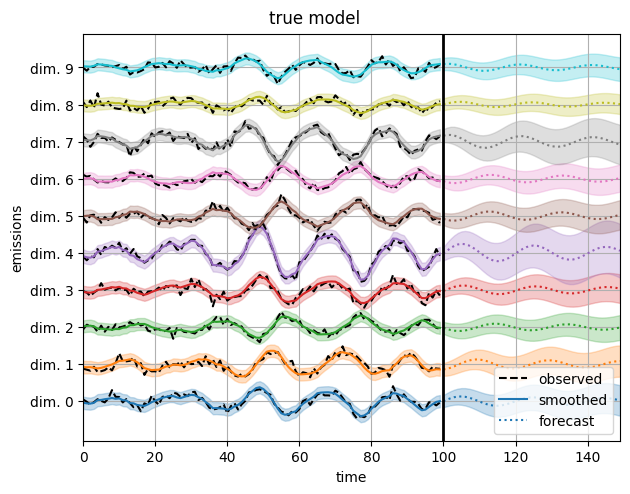

In [5]:
# plot_states_and_emissions(true_model, true_params, emissions)
plot_emissions_and_forecast(true_model, true_params, emissions)
plt.suptitle("true model", y=1.02)

In [6]:
# Plot predictions from a random, untrained model
init_key = jr.PRNGKey(42)
model = LinearGaussianSSM(state_dim, emission_dim)
params, param_props = model.initialize(init_key)

Text(0.5, 1.02, 'randomly initialized model')

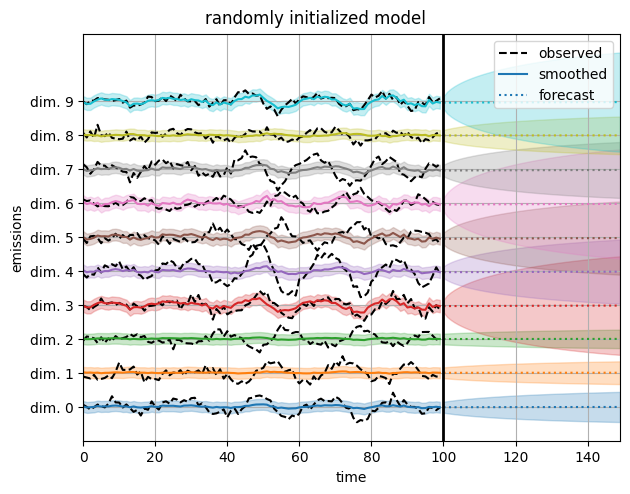

In [7]:
plot_emissions_and_forecast(model, params, emissions)
plt.suptitle("randomly initialized model", y=1.02)

In [8]:
params, marginal_lls = model.fit_em(params, param_props, emissions, num_iters=100)
assert monotonically_increasing(marginal_lls, atol=1e-2, rtol=1e-2)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:00&lt;00:00]</div>

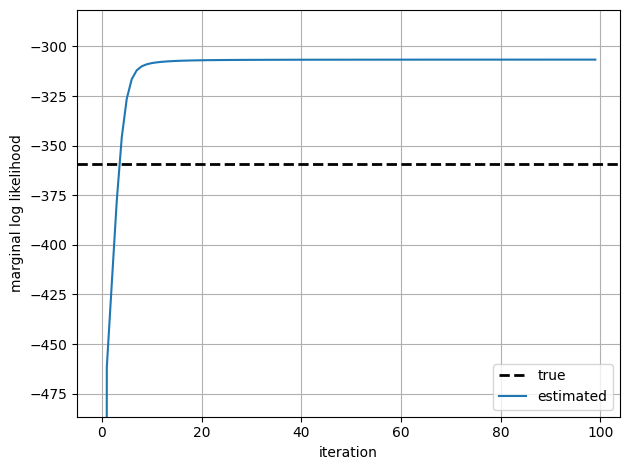

In [9]:
true_ll = true_model.marginal_log_prob(true_params, emissions)
plt.axhline(true_ll, color = 'k', linestyle = '--', lw=2, label="true")
plt.plot(marginal_lls, '-', ms=4, label="estimated")
plt.xlabel("iteration")
plt.ylabel("marginal log likelihood")
plt.ylim(marginal_lls[1] - 25, marginal_lls[-1] + 25)
plt.legend()
plt.tight_layout()
plt.grid(True)

Text(0.5, 1.02, 'fitted model')

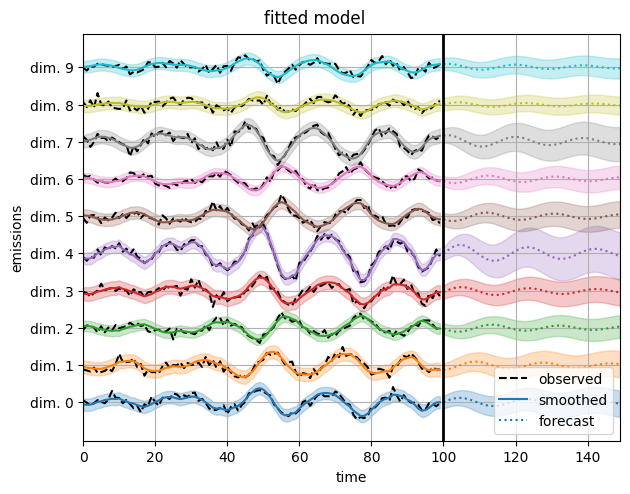

In [10]:
plot_emissions_and_forecast(model, params, emissions)
plt.suptitle("fitted model", y=1.02)